In [19]:
# import packages
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import statistics
import scipy.stats as stats

In [21]:
# allow matplotlib inline plotting
%matplotlib inline

In [23]:
# load the churn data into a dataframe, keep None as not-null, and create a backup
churn_file = 'churn_raw_data.csv'
df = pd.read_csv(churn_file)
df.fillna({'InternetService': 'None'}, inplace=True)
df_backup = df.copy()

In [25]:
# show profile of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            10000 non-null  int64  
 1   CaseOrder             10000 non-null  int64  
 2   Customer_id           10000 non-null  object 
 3   Interaction           10000 non-null  object 
 4   City                  10000 non-null  object 
 5   State                 10000 non-null  object 
 6   County                10000 non-null  object 
 7   Zip                   10000 non-null  int64  
 8   Lat                   10000 non-null  float64
 9   Lng                   10000 non-null  float64
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  object 
 12  Timezone              10000 non-null  object 
 13  Job                   10000 non-null  object 
 14  Children              7505 non-null   float64
 15  Age                 

In [27]:
# look for duplicates
print(df.duplicated().value_counts())

False    10000
Name: count, dtype: int64


In [29]:
# check for null values in the columns
df.isnull().sum()

Unnamed: 0                 0
CaseOrder                  0
Customer_id                0
Interaction                0
City                       0
State                      0
County                     0
Zip                        0
Lat                        0
Lng                        0
Population                 0
Area                       0
Timezone                   0
Job                        0
Children                2495
Age                     2475
Education                  0
Employment                 0
Income                  2490
Marital                    0
Gender                     0
Churn                      0
Outage_sec_perweek         0
Email                      0
Contacts                   0
Yearly_equip_failure       0
Techie                  2477
Contract                   0
Port_modem                 0
Tablet                     0
InternetService            0
Phone                   1026
Multiple                   0
OnlineSecurity             0
OnlineBackup  

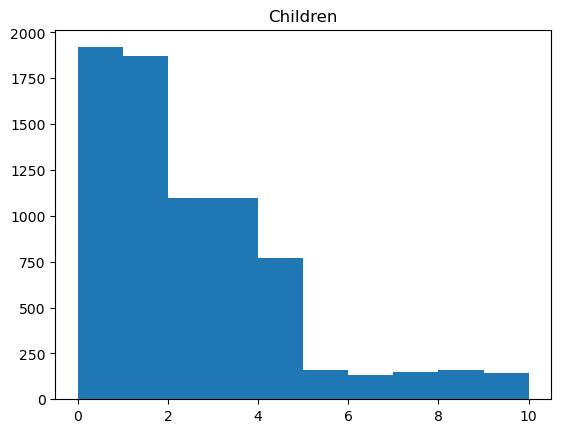

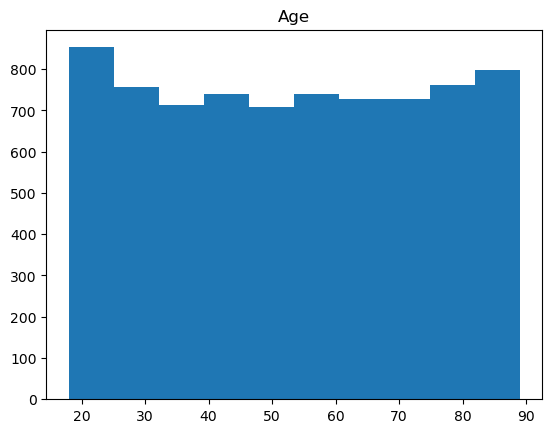

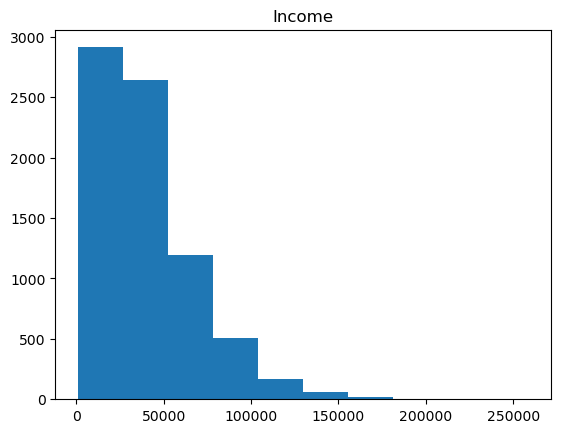

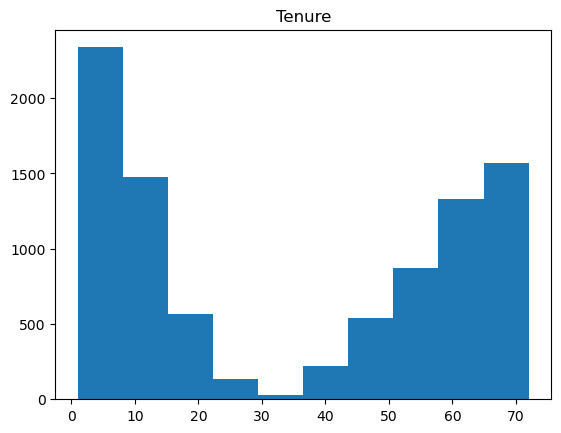

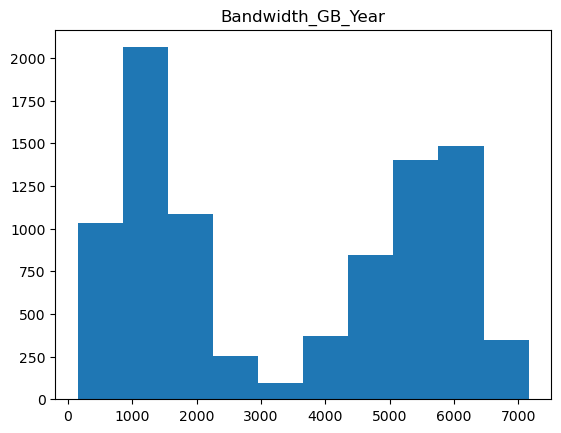

In [31]:
# view histograms of the numeric variables containing nulls
plt.hist(df['Children'])
plt.title('Children')
plt.show()
plt.hist(df['Age'])
plt.title('Age')
plt.show()
plt.hist(df['Income'])
plt.title('Income')
plt.show()
plt.hist(df['Tenure'])
plt.title('Tenure')
plt.show()
plt.hist(df['Bandwidth_GB_Year'])
plt.title('Bandwidth_GB_Year')
plt.show()

In [33]:
# check the median before imputation
df['Children'].median()

1.0

In [35]:
# check the mean before imputation
df['Age'].mean()

53.27574750830565

In [37]:
# check the median before imputation
df['Income'].median()

33186.785

In [39]:
# check the median before imputation
df['Tenure'].median()

36.19603

In [41]:
# check the median before imputation
df['Bandwidth_GB_Year'].median()

3382.424

In [43]:
# impute the missing values for numeric variables
df.fillna({'Children': df['Children'].median()}, inplace=True) # skewed distribution, using median
df.fillna({'Age': df['Age'].mean()}, inplace=True) # normal distribution, using mean
df.fillna({'Income': df['Income'].median()}, inplace=True) # skewed distribution, using median
df.fillna({'Tenure': df['Tenure'].median()}, inplace=True) # bimodal numeric distribution, using median
df.fillna({'Bandwidth_GB_Year': df['Bandwidth_GB_Year'].median()}, inplace=True) # bimodal numeric distribution, using median

In [45]:
# verify imputation by checking for nulls
df.isnull().sum()

Unnamed: 0                 0
CaseOrder                  0
Customer_id                0
Interaction                0
City                       0
State                      0
County                     0
Zip                        0
Lat                        0
Lng                        0
Population                 0
Area                       0
Timezone                   0
Job                        0
Children                   0
Age                        0
Education                  0
Employment                 0
Income                     0
Marital                    0
Gender                     0
Churn                      0
Outage_sec_perweek         0
Email                      0
Contacts                   0
Yearly_equip_failure       0
Techie                  2477
Contract                   0
Port_modem                 0
Tablet                     0
InternetService            0
Phone                   1026
Multiple                   0
OnlineSecurity             0
OnlineBackup  

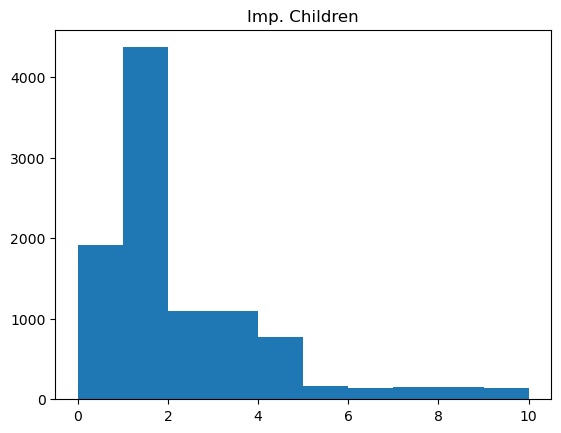

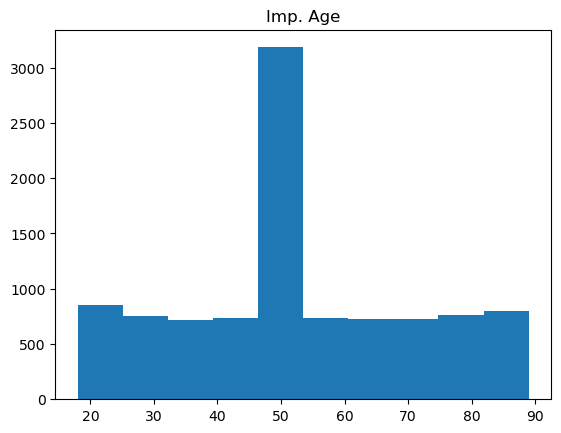

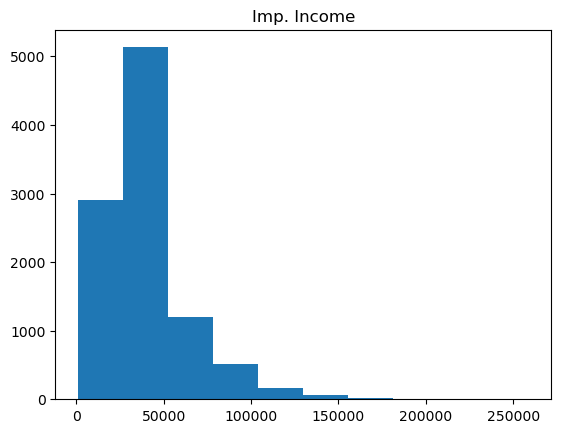

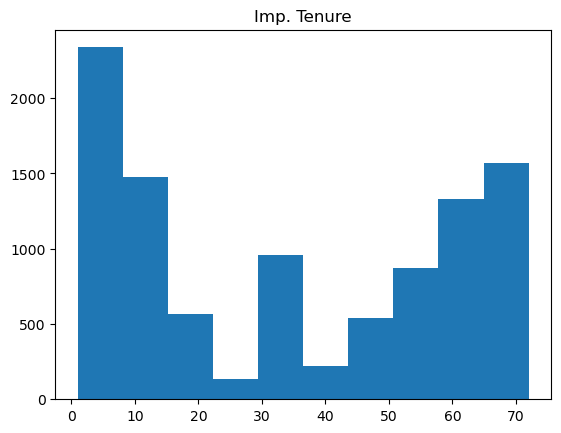

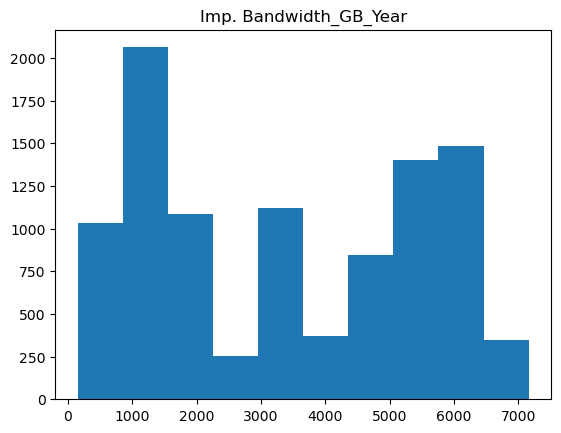

In [47]:
# verify imputation did not change distribution type
plt.hist(df['Children'])
plt.title('Imp. Children')
plt.show()
plt.hist(df['Age'])
plt.title('Imp. Age')
plt.show()
plt.hist(df['Income'])
plt.title('Imp. Income')
plt.show()
plt.hist(df['Tenure'])
plt.title('Imp. Tenure')
plt.show()
plt.hist(df['Bandwidth_GB_Year'])
plt.title('Imp. Bandwidth_GB_Year')
plt.show()

In [49]:
# verify median after imputation
df['Children'].median()

1.0

In [51]:
# verify mean after imputation
df['Age'].mean()

53.27574750830565

In [53]:
# verify median after imputation
df['Income'].median()

33186.785

In [55]:
# verify median after imputation
df['Tenure'].median()

36.19603

In [57]:
# verify median after imputation
df['Bandwidth_GB_Year'].median()

3382.424

In [59]:
# view the count of unique values per column
df.nunique()

Unnamed: 0              10000
CaseOrder               10000
Customer_id             10000
Interaction             10000
City                     6058
State                      52
County                   1620
Zip                      8583
Lat                      8563
Lng                      8655
Population               5933
Area                        3
Timezone                   25
Job                       639
Children                   11
Age                        73
Education                  12
Employment                  5
Income                   7507
Marital                     5
Gender                      3
Churn                       2
Outage_sec_perweek       9993
Email                      23
Contacts                    8
Yearly_equip_failure        6
Techie                      2
Contract                    3
Port_modem                  2
Tablet                      2
InternetService             3
Phone                       2
Multiple                    2
OnlineSecu

In [61]:
# view the unique values in Techie before imputation
df['Techie'].unique()

array(['No', 'Yes', nan], dtype=object)

In [63]:
# view the unique values in Phone before imputation
df['Phone'].unique()

array(['Yes', 'No', nan], dtype=object)

In [65]:
# view the unique values in TechSupport before imputation
df['TechSupport'].unique()

array(['No', 'Yes', nan], dtype=object)

In [67]:
# calculate mode for Techie
techie_mode = df['Techie'].mode()[0]

In [69]:
# calculate mode for Phone
phone_mode = df['Phone'].mode()[0]

In [71]:
# calculate mode for TechSupport
techsupport_mode = df['TechSupport'].mode()[0]

In [73]:
# impute the categorical variables with null values using mode
df['Techie'] = df['Techie'].fillna(techie_mode)
df['Phone'] = df['Phone'].fillna(phone_mode)
df['TechSupport'] = df['TechSupport'].fillna(techsupport_mode)

In [75]:
# view nulls again to verify there are no null values in the dataframe
df.isnull().sum()

Unnamed: 0              0
CaseOrder               0
Customer_id             0
Interaction             0
City                    0
State                   0
County                  0
Zip                     0
Lat                     0
Lng                     0
Population              0
Area                    0
Timezone                0
Job                     0
Children                0
Age                     0
Education               0
Employment              0
Income                  0
Marital                 0
Gender                  0
Churn                   0
Outage_sec_perweek      0
Email                   0
Contacts                0
Yearly_equip_failure    0
Techie                  0
Contract                0
Port_modem              0
Tablet                  0
InternetService         0
Phone                   0
Multiple                0
OnlineSecurity          0
OnlineBackup            0
DeviceProtection        0
TechSupport             0
StreamingTV             0
StreamingMov

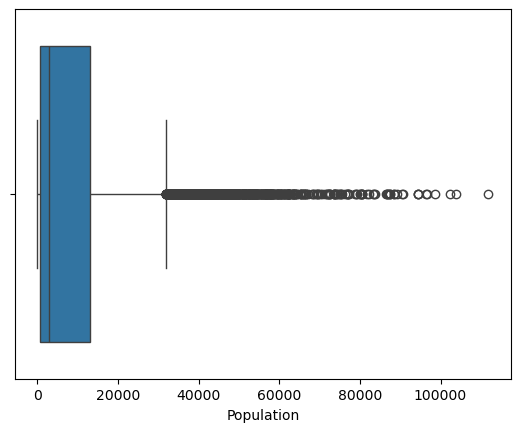

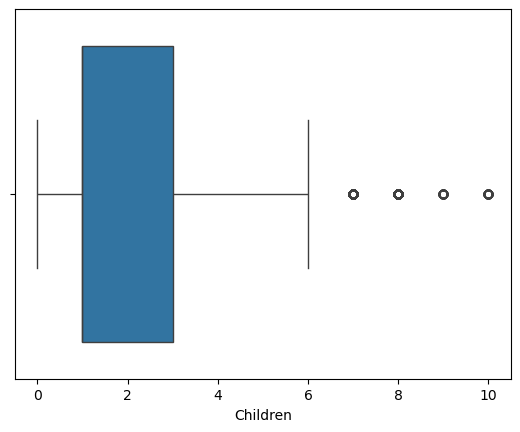

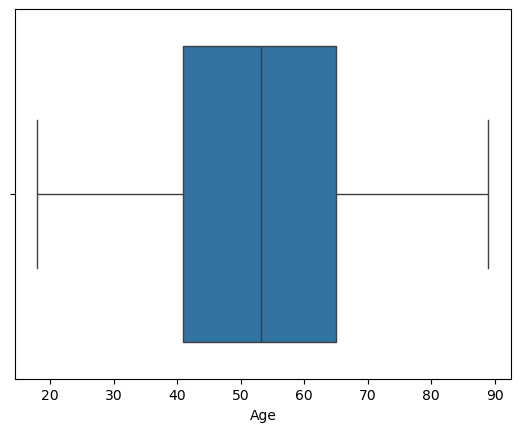

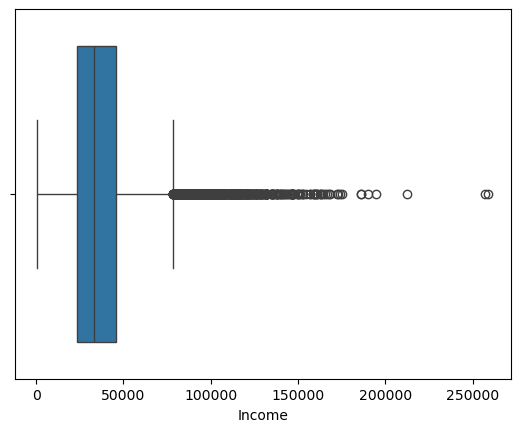

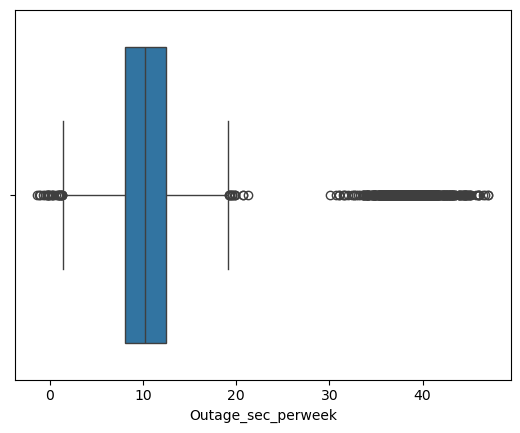

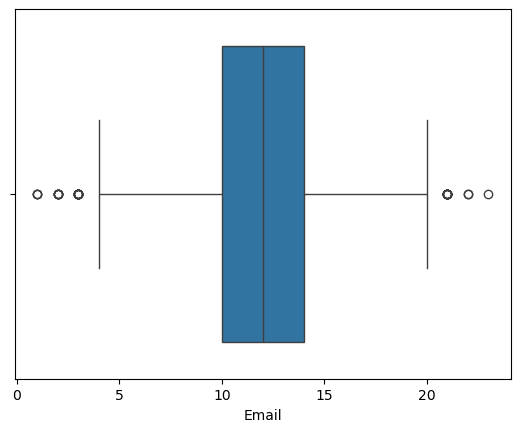

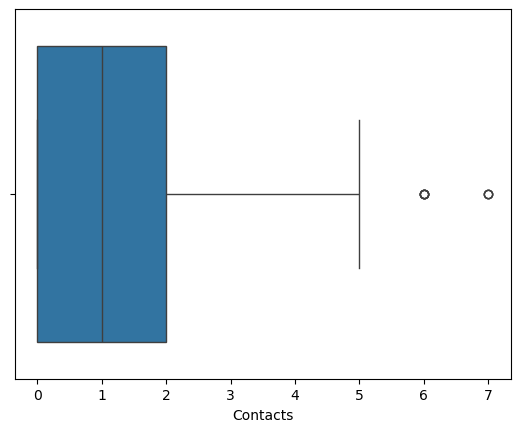

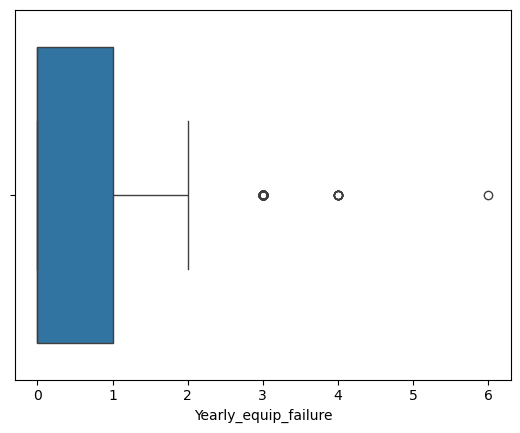

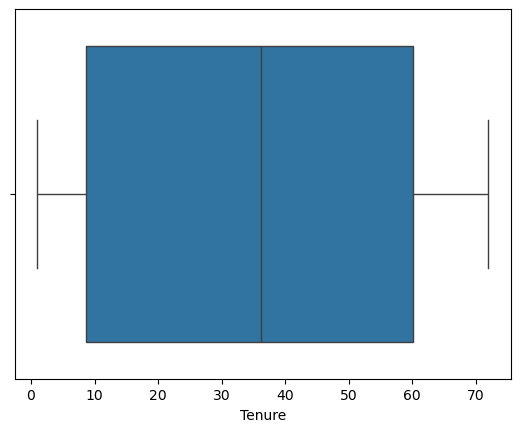

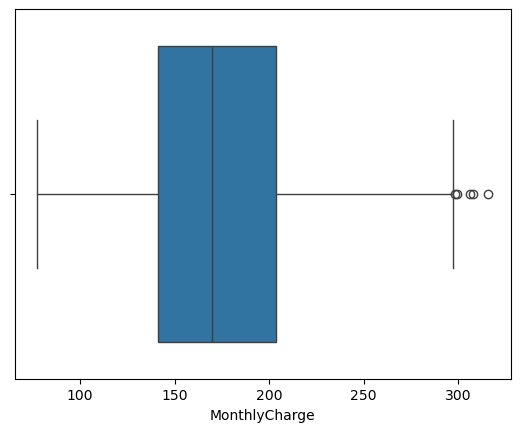

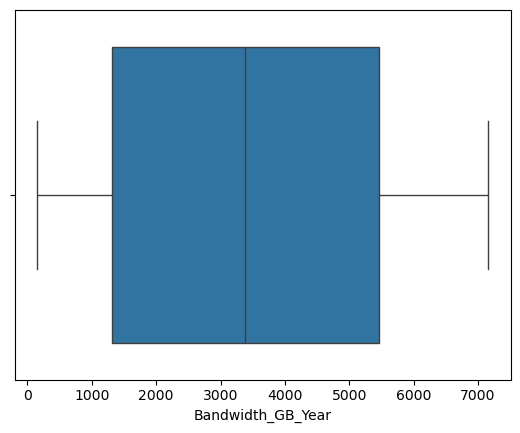

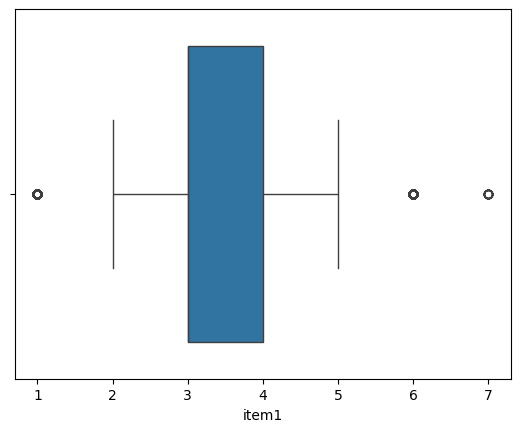

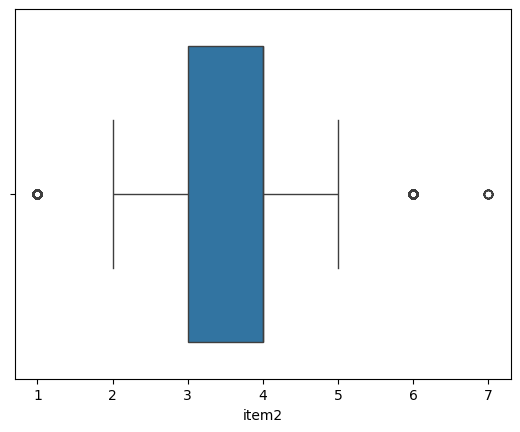

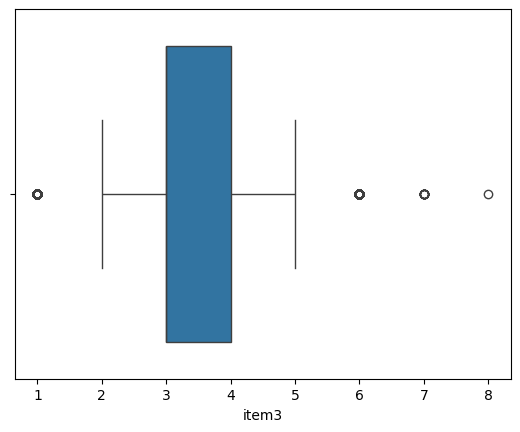

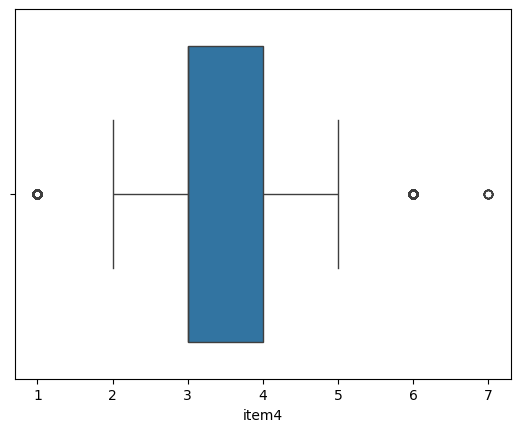

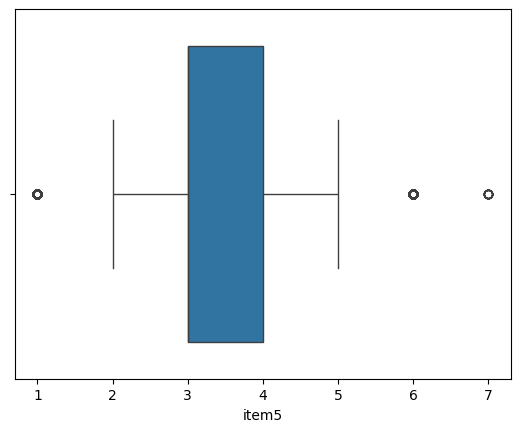

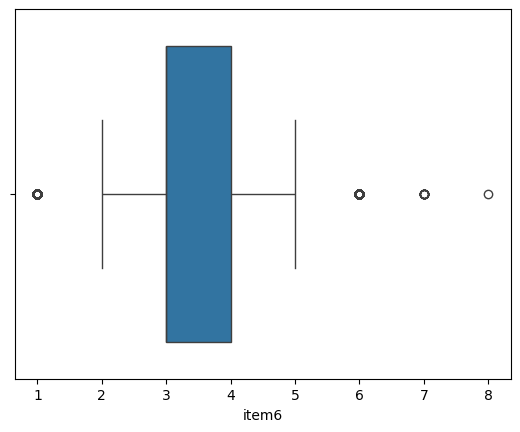

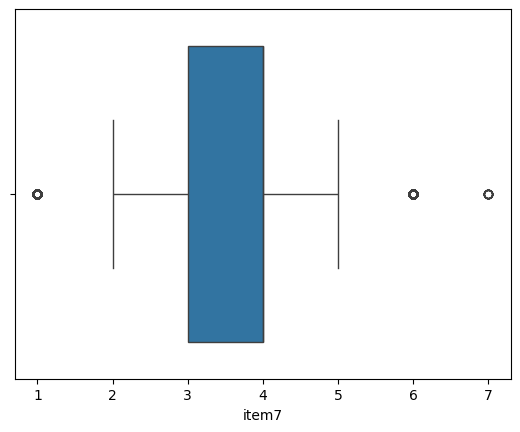

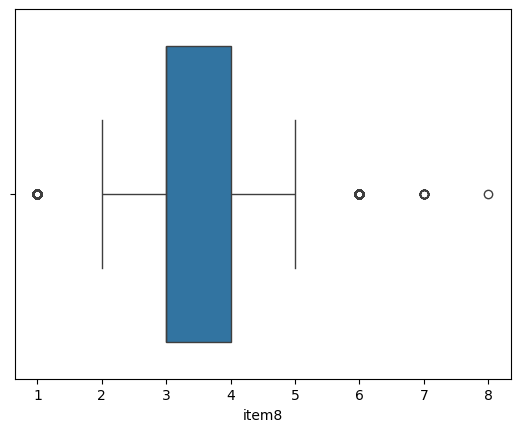

In [77]:
# create boxplots of numeric columns
sns.boxplot(x='Population', data=df)
plt.show()
sns.boxplot(x='Children', data=df)
plt.show()
sns.boxplot(x='Age', data=df)
plt.show()
sns.boxplot(x='Income', data=df)
plt.show()
sns.boxplot(x='Outage_sec_perweek', data=df)
plt.show()
sns.boxplot(x='Email', data=df)
plt.show()
sns.boxplot(x='Contacts', data=df)
plt.show()
sns.boxplot(x='Yearly_equip_failure', data=df)
plt.show()
sns.boxplot(x='Tenure', data=df)
plt.show()
sns.boxplot(x='MonthlyCharge', data=df)
plt.show()
sns.boxplot(x='Bandwidth_GB_Year', data=df)
plt.show()
sns.boxplot(x='item1', data=df)
plt.show()
sns.boxplot(x='item2', data=df)
plt.show()
sns.boxplot(x='item3', data=df)
plt.show()
sns.boxplot(x='item4', data=df)
plt.show()
sns.boxplot(x='item5', data=df)
plt.show()
sns.boxplot(x='item6', data=df)
plt.show()
sns.boxplot(x='item7', data=df)
plt.show()
sns.boxplot(x='item8', data=df)
plt.show()

In [79]:
# grab the range and count of population outliers
population_query = df.query('Population > 35000')
population_query.info()

<class 'pandas.core.frame.DataFrame'>
Index: 773 entries, 16 to 9998
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            773 non-null    int64  
 1   CaseOrder             773 non-null    int64  
 2   Customer_id           773 non-null    object 
 3   Interaction           773 non-null    object 
 4   City                  773 non-null    object 
 5   State                 773 non-null    object 
 6   County                773 non-null    object 
 7   Zip                   773 non-null    int64  
 8   Lat                   773 non-null    float64
 9   Lng                   773 non-null    float64
 10  Population            773 non-null    int64  
 11  Area                  773 non-null    object 
 12  Timezone              773 non-null    object 
 13  Job                   773 non-null    object 
 14  Children              773 non-null    float64
 15  Age                   773 

In [81]:
# grab the range and count of children outliers
children_query = df.query('Children > 6')
children_query.info()

<class 'pandas.core.frame.DataFrame'>
Index: 451 entries, 10 to 9982
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            451 non-null    int64  
 1   CaseOrder             451 non-null    int64  
 2   Customer_id           451 non-null    object 
 3   Interaction           451 non-null    object 
 4   City                  451 non-null    object 
 5   State                 451 non-null    object 
 6   County                451 non-null    object 
 7   Zip                   451 non-null    int64  
 8   Lat                   451 non-null    float64
 9   Lng                   451 non-null    float64
 10  Population            451 non-null    int64  
 11  Area                  451 non-null    object 
 12  Timezone              451 non-null    object 
 13  Job                   451 non-null    object 
 14  Children              451 non-null    float64
 15  Age                   451 

In [83]:
# grab the range and count of income outliers
income_query = df.query('Income > 80000')
income_query.info()

<class 'pandas.core.frame.DataFrame'>
Index: 709 entries, 12 to 9987
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            709 non-null    int64  
 1   CaseOrder             709 non-null    int64  
 2   Customer_id           709 non-null    object 
 3   Interaction           709 non-null    object 
 4   City                  709 non-null    object 
 5   State                 709 non-null    object 
 6   County                709 non-null    object 
 7   Zip                   709 non-null    int64  
 8   Lat                   709 non-null    float64
 9   Lng                   709 non-null    float64
 10  Population            709 non-null    int64  
 11  Area                  709 non-null    object 
 12  Timezone              709 non-null    object 
 13  Job                   709 non-null    object 
 14  Children              709 non-null    float64
 15  Age                   709 

In [85]:
# grab the range and count of outage_sec_perweek outliers
outage_sec_perweek_query = df.query('Outage_sec_perweek < 1')
outage_sec_perweek_query.info()
outage_sec_perweek_query2 = df.query('Outage_sec_perweek > 20')
outage_sec_perweek_query2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 908 to 9402
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            20 non-null     int64  
 1   CaseOrder             20 non-null     int64  
 2   Customer_id           20 non-null     object 
 3   Interaction           20 non-null     object 
 4   City                  20 non-null     object 
 5   State                 20 non-null     object 
 6   County                20 non-null     object 
 7   Zip                   20 non-null     int64  
 8   Lat                   20 non-null     float64
 9   Lng                   20 non-null     float64
 10  Population            20 non-null     int64  
 11  Area                  20 non-null     object 
 12  Timezone              20 non-null     object 
 13  Job                   20 non-null     object 
 14  Children              20 non-null     float64
 15  Age                   20 n

In [87]:
# grab the range and count of email outliers
email_query = df.query('Email < 4')
email_query.info()
email_query2 = df.query('Email > 20')
email_query2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23 entries, 92 to 9339
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            23 non-null     int64  
 1   CaseOrder             23 non-null     int64  
 2   Customer_id           23 non-null     object 
 3   Interaction           23 non-null     object 
 4   City                  23 non-null     object 
 5   State                 23 non-null     object 
 6   County                23 non-null     object 
 7   Zip                   23 non-null     int64  
 8   Lat                   23 non-null     float64
 9   Lng                   23 non-null     float64
 10  Population            23 non-null     int64  
 11  Area                  23 non-null     object 
 12  Timezone              23 non-null     object 
 13  Job                   23 non-null     object 
 14  Children              23 non-null     float64
 15  Age                   23 no

In [89]:
# grab the range and count of contacts outliers
contacts_query = df.query('Contacts > 5')
contacts_query.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, 426 to 9750
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            8 non-null      int64  
 1   CaseOrder             8 non-null      int64  
 2   Customer_id           8 non-null      object 
 3   Interaction           8 non-null      object 
 4   City                  8 non-null      object 
 5   State                 8 non-null      object 
 6   County                8 non-null      object 
 7   Zip                   8 non-null      int64  
 8   Lat                   8 non-null      float64
 9   Lng                   8 non-null      float64
 10  Population            8 non-null      int64  
 11  Area                  8 non-null      object 
 12  Timezone              8 non-null      object 
 13  Job                   8 non-null      object 
 14  Children              8 non-null      float64
 15  Age                   8 non

In [91]:
# grab the range and count of yearly_equip_failure outliers
yearly_equip_failure_query = df.query('Yearly_equip_failure > 2')
yearly_equip_failure_query.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94 entries, 8 to 9967
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            94 non-null     int64  
 1   CaseOrder             94 non-null     int64  
 2   Customer_id           94 non-null     object 
 3   Interaction           94 non-null     object 
 4   City                  94 non-null     object 
 5   State                 94 non-null     object 
 6   County                94 non-null     object 
 7   Zip                   94 non-null     int64  
 8   Lat                   94 non-null     float64
 9   Lng                   94 non-null     float64
 10  Population            94 non-null     int64  
 11  Area                  94 non-null     object 
 12  Timezone              94 non-null     object 
 13  Job                   94 non-null     object 
 14  Children              94 non-null     float64
 15  Age                   94 non

In [93]:
# grab the range and count of monthlycharge outliers
monthlycharge_query = df.query('MonthlyCharge > 290')
monthlycharge_query.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18 entries, 798 to 8755
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            18 non-null     int64  
 1   CaseOrder             18 non-null     int64  
 2   Customer_id           18 non-null     object 
 3   Interaction           18 non-null     object 
 4   City                  18 non-null     object 
 5   State                 18 non-null     object 
 6   County                18 non-null     object 
 7   Zip                   18 non-null     int64  
 8   Lat                   18 non-null     float64
 9   Lng                   18 non-null     float64
 10  Population            18 non-null     int64  
 11  Area                  18 non-null     object 
 12  Timezone              18 non-null     object 
 13  Job                   18 non-null     object 
 14  Children              18 non-null     float64
 15  Age                   18 n

In [95]:
# grab the range and count of item1 outliers
item1_query = df.query('item1 > 5')
item1_query.info()
item1_query2 = df.query('item1 < 2')
item1_query2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 218 entries, 6 to 9984
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            218 non-null    int64  
 1   CaseOrder             218 non-null    int64  
 2   Customer_id           218 non-null    object 
 3   Interaction           218 non-null    object 
 4   City                  218 non-null    object 
 5   State                 218 non-null    object 
 6   County                218 non-null    object 
 7   Zip                   218 non-null    int64  
 8   Lat                   218 non-null    float64
 9   Lng                   218 non-null    float64
 10  Population            218 non-null    int64  
 11  Area                  218 non-null    object 
 12  Timezone              218 non-null    object 
 13  Job                   218 non-null    object 
 14  Children              218 non-null    float64
 15  Age                   218 n

In [97]:
# grab the range and count of item2 outliers
item2_query = df.query('item2 > 5')
item2_query.info()
item2_query2 = df.query('item2 < 2')
item2_query2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 228 entries, 13 to 9916
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            228 non-null    int64  
 1   CaseOrder             228 non-null    int64  
 2   Customer_id           228 non-null    object 
 3   Interaction           228 non-null    object 
 4   City                  228 non-null    object 
 5   State                 228 non-null    object 
 6   County                228 non-null    object 
 7   Zip                   228 non-null    int64  
 8   Lat                   228 non-null    float64
 9   Lng                   228 non-null    float64
 10  Population            228 non-null    int64  
 11  Area                  228 non-null    object 
 12  Timezone              228 non-null    object 
 13  Job                   228 non-null    object 
 14  Children              228 non-null    float64
 15  Age                   228 

In [99]:
# grab the range and count of item3 outliers
item3_query = df.query('item3 > 5')
item3_query.info()
item3_query2 = df.query('item3 < 2')
item3_query2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 216 entries, 6 to 9998
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            216 non-null    int64  
 1   CaseOrder             216 non-null    int64  
 2   Customer_id           216 non-null    object 
 3   Interaction           216 non-null    object 
 4   City                  216 non-null    object 
 5   State                 216 non-null    object 
 6   County                216 non-null    object 
 7   Zip                   216 non-null    int64  
 8   Lat                   216 non-null    float64
 9   Lng                   216 non-null    float64
 10  Population            216 non-null    int64  
 11  Area                  216 non-null    object 
 12  Timezone              216 non-null    object 
 13  Job                   216 non-null    object 
 14  Children              216 non-null    float64
 15  Age                   216 n

In [101]:
# grab the range and count of item4 outliers
item4_query = df.query('item4 > 5')
item4_query.info()
item4_query2 = df.query('item4 < 2')
item4_query2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 212 entries, 10 to 9950
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            212 non-null    int64  
 1   CaseOrder             212 non-null    int64  
 2   Customer_id           212 non-null    object 
 3   Interaction           212 non-null    object 
 4   City                  212 non-null    object 
 5   State                 212 non-null    object 
 6   County                212 non-null    object 
 7   Zip                   212 non-null    int64  
 8   Lat                   212 non-null    float64
 9   Lng                   212 non-null    float64
 10  Population            212 non-null    int64  
 11  Area                  212 non-null    object 
 12  Timezone              212 non-null    object 
 13  Job                   212 non-null    object 
 14  Children              212 non-null    float64
 15  Age                   212 

In [103]:
# grab the range and count of item5 outliers
item5_query = df.query('item5 > 5')
item5_query.info()
item5_query2 = df.query('item5 < 2')
item5_query2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 216 entries, 137 to 9977
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            216 non-null    int64  
 1   CaseOrder             216 non-null    int64  
 2   Customer_id           216 non-null    object 
 3   Interaction           216 non-null    object 
 4   City                  216 non-null    object 
 5   State                 216 non-null    object 
 6   County                216 non-null    object 
 7   Zip                   216 non-null    int64  
 8   Lat                   216 non-null    float64
 9   Lng                   216 non-null    float64
 10  Population            216 non-null    int64  
 11  Area                  216 non-null    object 
 12  Timezone              216 non-null    object 
 13  Job                   216 non-null    object 
 14  Children              216 non-null    float64
 15  Age                   216

In [105]:
# grab the range and count of item6 outliers
item6_query = df.query('item6 > 5')
item6_query.info()
item6_query2 = df.query('item6 < 2')
item6_query2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 223 entries, 34 to 9916
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            223 non-null    int64  
 1   CaseOrder             223 non-null    int64  
 2   Customer_id           223 non-null    object 
 3   Interaction           223 non-null    object 
 4   City                  223 non-null    object 
 5   State                 223 non-null    object 
 6   County                223 non-null    object 
 7   Zip                   223 non-null    int64  
 8   Lat                   223 non-null    float64
 9   Lng                   223 non-null    float64
 10  Population            223 non-null    int64  
 11  Area                  223 non-null    object 
 12  Timezone              223 non-null    object 
 13  Job                   223 non-null    object 
 14  Children              223 non-null    float64
 15  Age                   223 

In [107]:
# grab the range and count of item7 outliers
item7_query = df.query('item7 > 5')
item7_query.info()
item7_query2 = df.query('item7 < 2')
item7_query2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 235 entries, 39 to 9898
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            235 non-null    int64  
 1   CaseOrder             235 non-null    int64  
 2   Customer_id           235 non-null    object 
 3   Interaction           235 non-null    object 
 4   City                  235 non-null    object 
 5   State                 235 non-null    object 
 6   County                235 non-null    object 
 7   Zip                   235 non-null    int64  
 8   Lat                   235 non-null    float64
 9   Lng                   235 non-null    float64
 10  Population            235 non-null    int64  
 11  Area                  235 non-null    object 
 12  Timezone              235 non-null    object 
 13  Job                   235 non-null    object 
 14  Children              235 non-null    float64
 15  Age                   235 

In [109]:
# grab the range and count of item8 outliers
item8_query = df.query('item8 > 5')
item8_query.info()
item8_query2 = df.query('item8 < 2')
item8_query2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 220 entries, 85 to 9936
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            220 non-null    int64  
 1   CaseOrder             220 non-null    int64  
 2   Customer_id           220 non-null    object 
 3   Interaction           220 non-null    object 
 4   City                  220 non-null    object 
 5   State                 220 non-null    object 
 6   County                220 non-null    object 
 7   Zip                   220 non-null    int64  
 8   Lat                   220 non-null    float64
 9   Lng                   220 non-null    float64
 10  Population            220 non-null    int64  
 11  Area                  220 non-null    object 
 12  Timezone              220 non-null    object 
 13  Job                   220 non-null    object 
 14  Children              220 non-null    float64
 15  Age                   220 

In [111]:
# change datatypes of Children and Age to int64
df['Children'] = df['Children'].astype(int)
df['Age'] = df['Age'].astype(int)

In [113]:
# verify the datatype changed
df['Children'].info()
df['Age'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: Children
Non-Null Count  Dtype
--------------  -----
10000 non-null  int32
dtypes: int32(1)
memory usage: 39.2 KB
<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: Age
Non-Null Count  Dtype
--------------  -----
10000 non-null  int32
dtypes: int32(1)
memory usage: 39.2 KB


In [115]:
# export cleaned data set
df.to_csv('churn_clean_data.csv')